# Fashion MNIST — CNN with Adversarial Robustness Analysis

A PyTorch CNN trained on Fashion MNIST, extended with **GradCAM explainability** and **FGSM adversarial robustness analysis** to find which garment classes are most exploitable at the pixel level.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision.datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import time, copy
import matplotlib.pyplot as plt
from sklearn import metrics as skmetrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Data

In [2]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot',
]

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1).numpy()

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(28, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

ds_full = torchvision.datasets.FashionMNIST('', train=True,  transform=transform_train, download=True)
ds_test = torchvision.datasets.FashionMNIST('', train=False, transform=transform_test,  download=True)

train_n = int(0.75 * len(ds_full))
ds_train, ds_val = torch.utils.data.random_split(ds_full, [train_n, len(ds_full) - train_n])

BATCH = 100
dataloaders = {
    'train': DataLoader(ds_train, batch_size=BATCH, shuffle=True),
    'val':   DataLoader(ds_val,   batch_size=BATCH, shuffle=False),
    'test':  DataLoader(ds_test,  batch_size=BATCH, shuffle=False),
}
dataset_sizes = {'train': len(ds_train), 'val': len(ds_val), 'test': len(ds_test)}
print(dataset_sizes)

{'train': 45000, 'val': 15000, 'test': 10000}


## 2. Exploratory Data Analysis

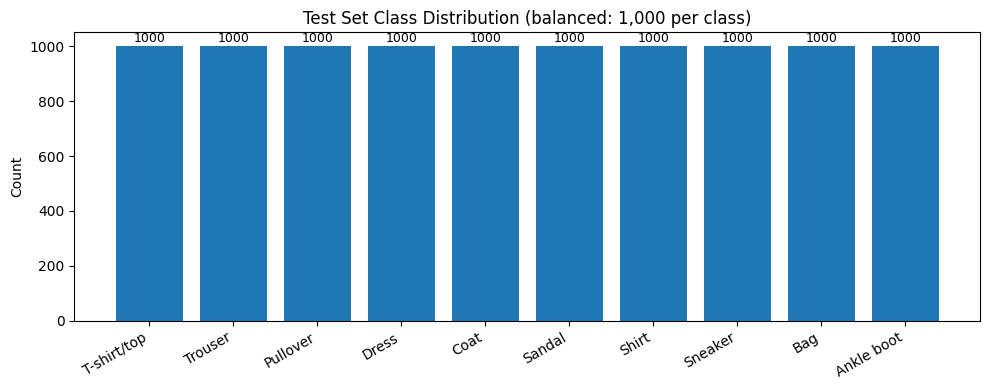

In [3]:
labels_all = [ds_test[i][1] for i in range(len(ds_test))]
counts = np.bincount(labels_all)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(10), counts)
ax.set_title('Test Set Class Distribution (balanced: 1,000 per class)')
ax.set_ylabel('Count')
ax.set_xticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

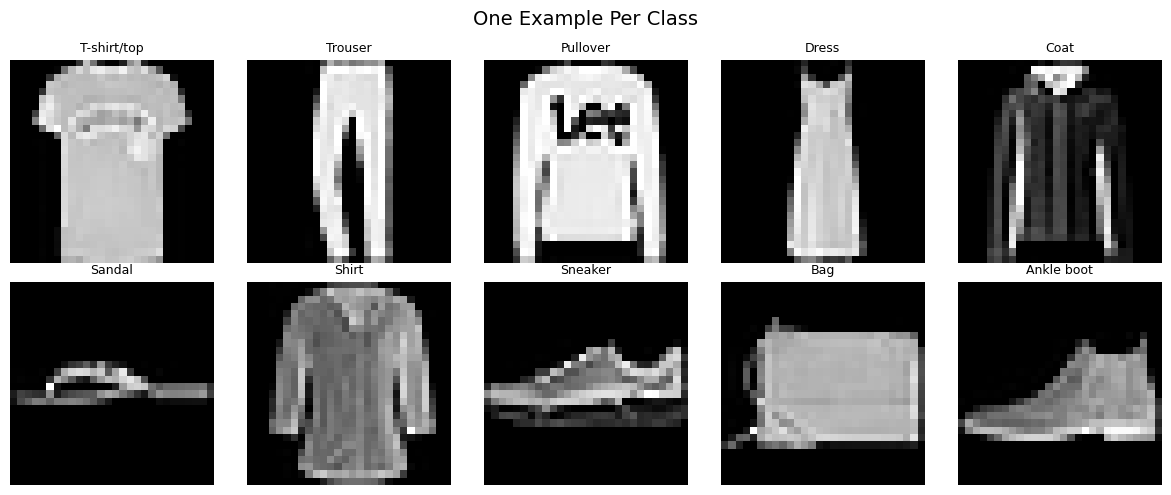

In [4]:
ds_raw = torchvision.datasets.FashionMNIST('', train=False, transform=transform_test, download=False)
found = {}
for img, label in ds_raw:
    if label not in found:
        found[label] = img
    if len(found) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One Example Per Class', fontsize=14)
for label in range(10):
    ax = axes[label // 5, label % 5]
    ax.imshow(denorm(found[label]).squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Model Architecture

Single conv block (8 filters, 3×3) → MaxPool → FC(128) → FC(10). Dropout at 0.25 and 0.5.

In [5]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.pipeline = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),  # -> [B, 8, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                         # -> [B, 8, 14, 14]
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(8 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.pipeline(x)

In [6]:
LR, NUM_EPOCHS = 0.0005, 10
criterion = nn.CrossEntropyLoss()

model     = CNNClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
print(model)

CNNClassifier(
  (pipeline): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=1568, out_features=128, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Training

In [7]:
def train_classification_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=25):
    since    = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    curves   = {f'{p}_{m}': [] for p in ['train', 'val', 'test'] for m in ['loss', 'acc']}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'val', 'test']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_correct = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss    += loss.item() * inputs.size(0)
                running_correct += (preds == labels).sum().item()

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss    / dataset_sizes[phase]
            epoch_acc  = running_correct / dataset_sizes[phase]
            curves[f'{phase}_loss'].append(epoch_loss)
            curves[f'{phase}_acc'].append(epoch_acc)
            print(f'  {phase:5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())

    elapsed = time.time() - since
    print(f'Done in {int(elapsed//60)}m {int(elapsed%60)}s  |  best val acc: {best_acc:.4f}')
    model.load_state_dict(best_wts)
    return model, curves

In [8]:
model, curves = train_classification_model(
    model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS
)

Epoch 1/10


  train  loss=1.0471  acc=0.6192


  val    loss=0.7081  acc=0.7337


  test   loss=0.6564  acc=0.7497
Epoch 2/10


  train  loss=0.7902  acc=0.7082


...

  val    loss=0.5381  acc=0.8013


  test   loss=0.4778  acc=0.8282
Epoch 10/10


  train  loss=0.6325  acc=0.7642


  val    loss=0.5278  acc=0.8044


  test   loss=0.4820  acc=0.8232
Done in 2m 54s  |  best val acc: 0.8044


## 5. Evaluation

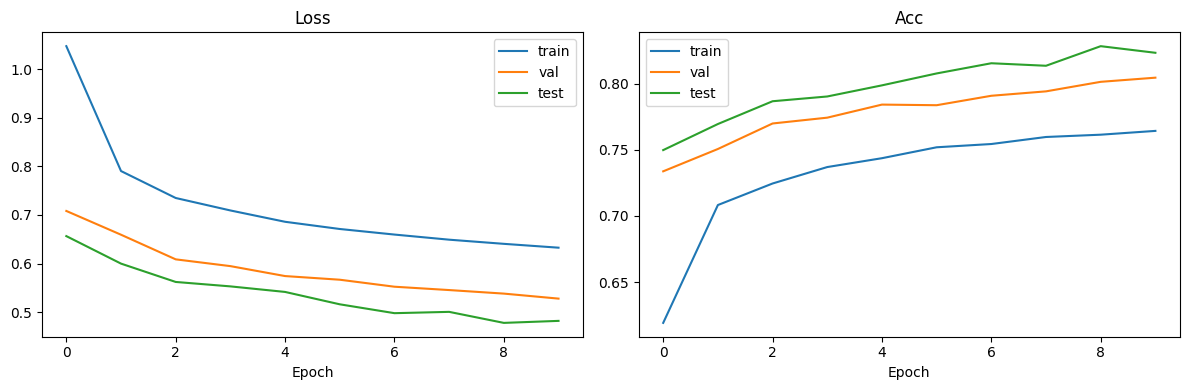

In [9]:
def plot_training_curves(curves):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ['loss', 'acc']):
        for phase in ['train', 'val', 'test']:
            ax.plot(curves[f'{phase}_{metric}'], label=phase)
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_training_curves(curves)

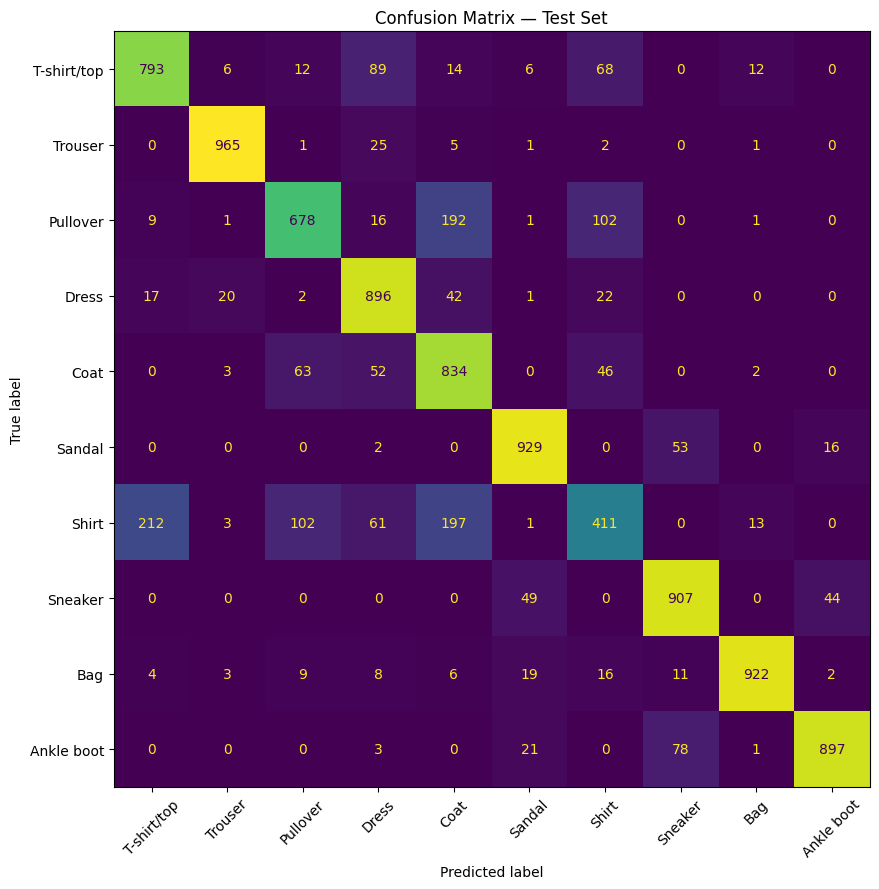

In [10]:
def get_predictions(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            preds = model(inputs.to(device)).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

preds, labels = get_predictions(model, dataloaders['test'])

cm = skmetrics.confusion_matrix(labels, preds)
disp = skmetrics.ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 9))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

In [11]:
print(skmetrics.classification_report(labels, preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.79      0.78      1000
     Trouser       0.96      0.96      0.96      1000
    Pullover       0.78      0.68      0.73      1000
       Dress       0.78      0.90      0.83      1000
        Coat       0.65      0.83      0.73      1000
      Sandal       0.90      0.93      0.92      1000
       Shirt       0.62      0.41      0.49      1000
     Sneaker       0.86      0.91      0.89      1000
         Bag       0.97      0.92      0.94      1000
  Ankle boot       0.94      0.90      0.92      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



## 6. Explainability — GradCAM

Gradient-weighted Class Activation Maps highlight which pixels most influence each class prediction. Hooks on the MaxPool layer capture activations and gradients; the weighted sum of feature maps is upsampled back to 28×28.

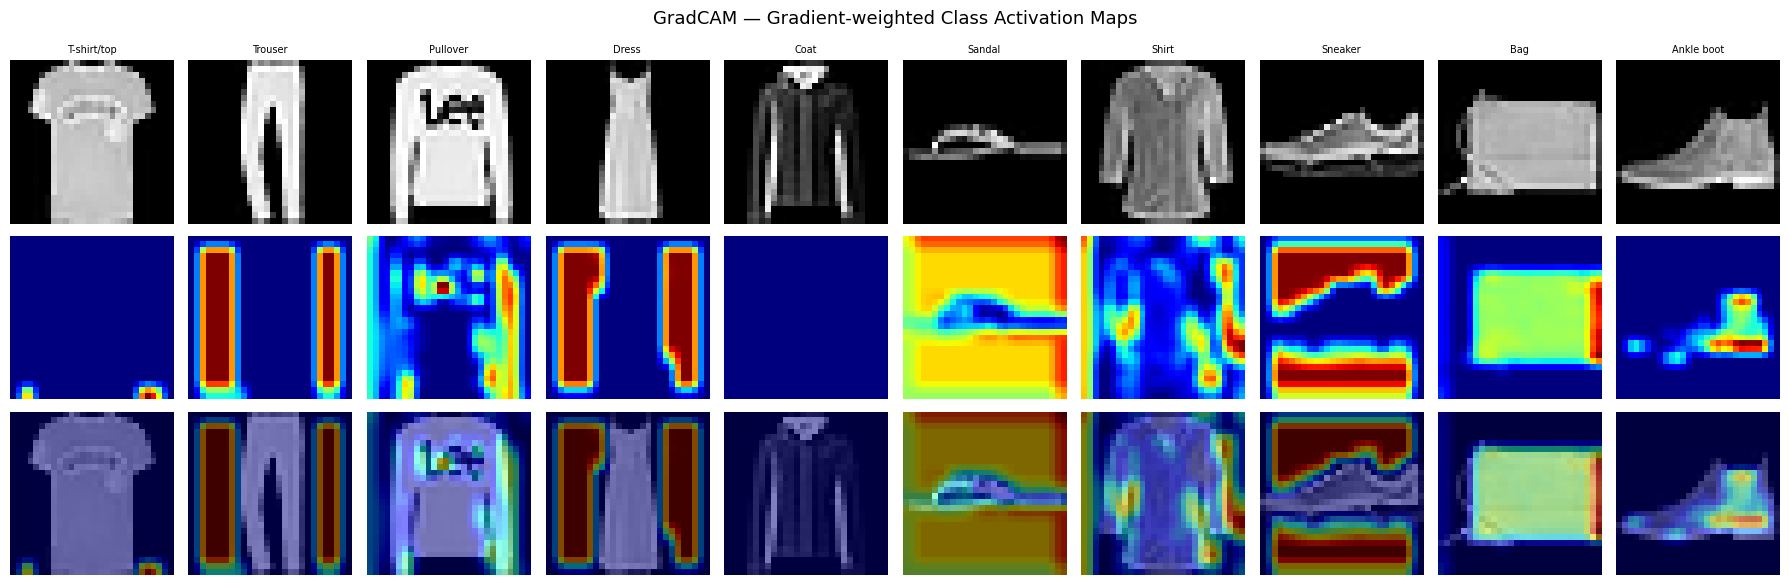

In [12]:
def gradcam(model, img_tensor, class_idx=None):
    model.eval()
    acts, grads = {}, {}

    def fwd_hook(m, inp, out): acts['v'] = out
    def bwd_hook(m, gi, go):   grads['v'] = go[0]

    h1 = model.pipeline[2].register_forward_hook(fwd_hook)
    h2 = model.pipeline[2].register_full_backward_hook(bwd_hook)

    x = img_tensor.unsqueeze(0).to(device)
    out = model(x)
    if class_idx is None:
        class_idx = out.argmax(dim=1).item()

    model.zero_grad()
    out[0, class_idx].backward()
    h1.remove(); h2.remove()

    weights = grads['v'].mean(dim=[2, 3], keepdim=True)
    cam = torch.relu((weights * acts['v']).sum(dim=1)).squeeze()
    cam = cam.detach().cpu().numpy()
    if cam.max() > 0:
        cam /= cam.max()

    cam_up = F.interpolate(
        torch.tensor(cam).unsqueeze(0).unsqueeze(0),
        size=(28, 28), mode='bilinear', align_corners=False,
    ).squeeze().numpy()
    return cam_up, class_idx


found_correct = {}
ds_raw = torchvision.datasets.FashionMNIST('', train=False, transform=transform_test, download=False)
for img, label in ds_raw:
    if label not in found_correct:
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax().item()
        if pred == label:
            found_correct[label] = img
    if len(found_correct) == 10:
        break

fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('GradCAM — Gradient-weighted Class Activation Maps', fontsize=13)

for label in range(10):
    img = found_correct[label]
    cam, _ = gradcam(model, img, class_idx=label)
    raw = denorm(img).squeeze()

    axes[0, label].imshow(raw, cmap='gray')
    axes[0, label].set_title(CLASS_NAMES[label], fontsize=7)
    axes[0, label].axis('off')

    axes[1, label].imshow(cam, cmap='jet')
    axes[1, label].axis('off')

    raw_rgb = np.stack([raw] * 3, axis=-1)
    cam_rgb = plt.get_cmap('jet')(cam)[:, :, :3]
    overlay = np.clip(0.5 * raw_rgb + 0.5 * cam_rgb, 0, 1)
    axes[2, label].imshow(overlay)
    axes[2, label].axis('off')

axes[0, 0].set_ylabel('Input',   fontsize=8)
axes[1, 0].set_ylabel('GradCAM', fontsize=8)
axes[2, 0].set_ylabel('Overlay', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Adversarial Robustness — FGSM

Fast Gradient Sign Method (Goodfellow et al., 2014) finds the minimal pixel perturbation along the loss gradient that flips the prediction:

$$x_{\text{adv}} = x + \varepsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f(x), y))$$

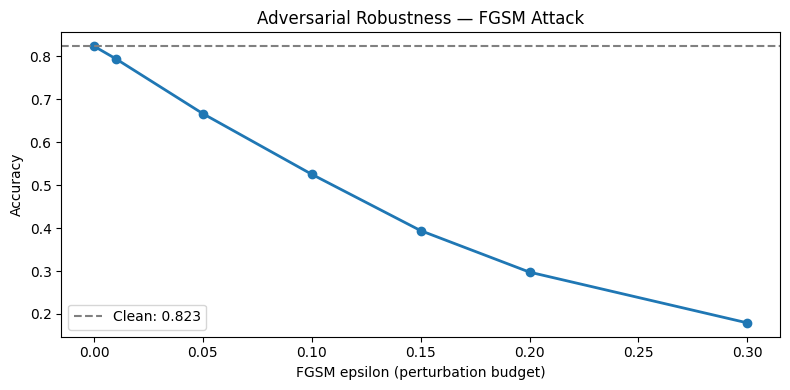

  eps=0.00  ->  acc=0.8232
  eps=0.01  ->  acc=0.7940
  eps=0.05  ->  acc=0.6662
  eps=0.10  ->  acc=0.5251
  eps=0.15  ->  acc=0.3940
  eps=0.20  ->  acc=0.2974
  eps=0.30  ->  acc=0.1793


In [13]:
def fgsm_attack(model, images, labels, epsilon):
    model.eval()
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    loss = criterion(model(images), labels)
    model.zero_grad()
    loss.backward()
    return torch.clamp(images + epsilon * images.grad.sign(), -1, 1).detach()

def adversarial_accuracy(model, dataloader, epsilon):
    correct, total = 0, 0
    for images, labels in dataloader:
        adv = fgsm_attack(model, images, labels, epsilon) if epsilon > 0 else images.to(device)
        with torch.no_grad():
            preds = model(adv).argmax(dim=1)
        correct += (preds == labels.to(device)).sum().item()
        total   += len(labels)
    return correct / total

epsilons = [0.0, 0.01, 0.05, 0.10, 0.15, 0.20, 0.30]
accs = [adversarial_accuracy(model, dataloaders['test'], eps) for eps in epsilons]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epsilons, accs, 'o-', linewidth=2)
ax.axhline(accs[0], color='gray', linestyle='--', label=f'Clean: {accs[0]:.3f}')
ax.set_xlabel('FGSM epsilon (perturbation budget)')
ax.set_ylabel('Accuracy')
ax.set_title('Adversarial Robustness — FGSM Attack')
ax.legend()
plt.tight_layout()
plt.show()

for eps, acc in zip(epsilons, accs):
    print(f'  eps={eps:.2f}  ->  acc={acc:.4f}')

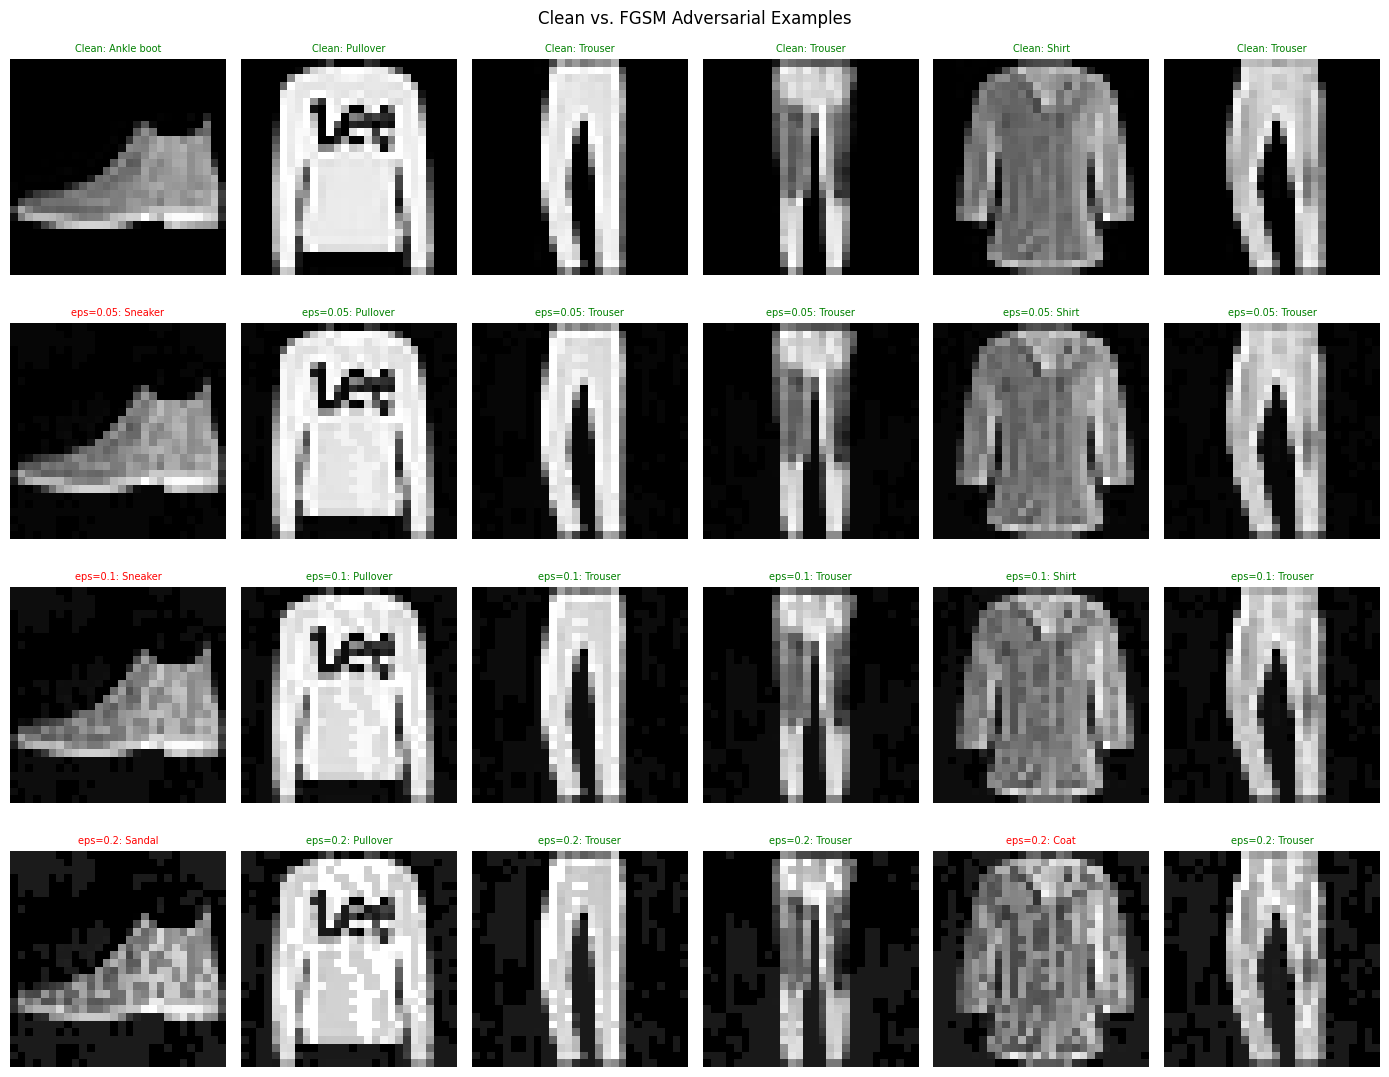

In [14]:
sample_imgs, sample_labels = next(iter(dataloaders['test']))
sample_imgs, sample_labels = sample_imgs[:6], sample_labels[:6]

eps_show = [0.05, 0.10, 0.20]
fig, axes = plt.subplots(1 + len(eps_show), 6, figsize=(14, 2.8 * (1 + len(eps_show))))
fig.suptitle('Clean vs. FGSM Adversarial Examples', fontsize=12)

def show_row(row_axes, imgs, labels_gt, prefix=''):
    for col, (img, lbl) in enumerate(zip(imgs, labels_gt)):
        ax = row_axes[col]
        ax.imshow(denorm(img).squeeze(), cmap='gray')
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax().item()
        color = 'green' if pred == lbl.item() else 'red'
        ax.set_title(f'{prefix}{CLASS_NAMES[pred]}', fontsize=7, color=color)
        ax.axis('off')

show_row(axes[0], sample_imgs, sample_labels, 'Clean: ')
for row, eps in enumerate(eps_show, 1):
    adv = fgsm_attack(model, sample_imgs, sample_labels, eps)
    show_row(axes[row], adv.cpu(), sample_labels, f'eps={eps}: ')
    axes[row][0].set_ylabel(f'eps={eps}', fontsize=8)

plt.tight_layout()
plt.show()

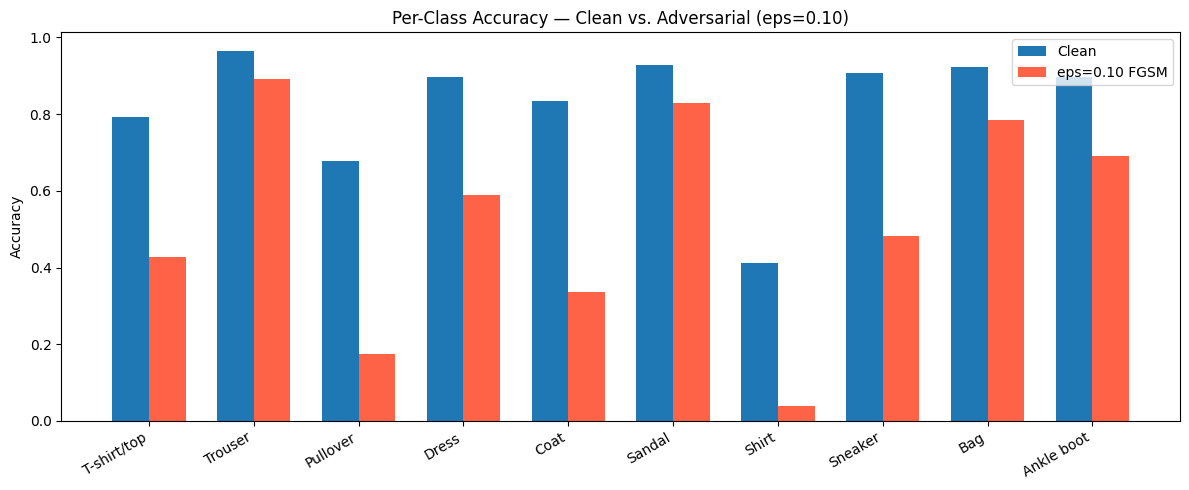

Per-class accuracy drop at eps=0.10:
  Pullover         clean=0.678  adv=0.175  drop=0.503
  Coat             clean=0.834  adv=0.337  drop=0.497
  Sneaker          clean=0.907  adv=0.483  drop=0.424
  Shirt            clean=0.411  adv=0.040  drop=0.371
  T-shirt/top      clean=0.793  adv=0.428  drop=0.365
  Dress            clean=0.896  adv=0.590  drop=0.306
  Ankle boot       clean=0.897  adv=0.691  drop=0.206
  Bag              clean=0.922  adv=0.785  drop=0.137
  Sandal           clean=0.929  adv=0.830  drop=0.099
  Trouser          clean=0.965  adv=0.892  drop=0.073


In [15]:
def class_accuracies(model, dataloader, epsilon):
    correct = np.zeros(10)
    total   = np.zeros(10)
    for images, labels in dataloader:
        adv = fgsm_attack(model, images, labels, epsilon) if epsilon > 0 else images.to(device)
        with torch.no_grad():
            preds = model(adv).argmax(dim=1).cpu()
        for i in range(10):
            mask = labels == i
            correct[i] += (preds[mask] == labels[mask]).sum().item()
            total[i]   += mask.sum().item()
    return correct / total

clean_acc = class_accuracies(model, dataloaders['test'], 0.0)
adv_acc   = class_accuracies(model, dataloaders['test'], 0.10)

x = np.arange(10)
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, clean_acc, w, label='Clean')
ax.bar(x + w/2, adv_acc,   w, label='eps=0.10 FGSM', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy — Clean vs. Adversarial (eps=0.10)')
ax.legend()
plt.tight_layout()
plt.show()

print('Per-class accuracy drop at eps=0.10:')
order = np.argsort(clean_acc - adv_acc)[::-1]
for i in order:
    drop = clean_acc[i] - adv_acc[i]
    print(f'  {CLASS_NAMES[i]:15s}  clean={clean_acc[i]:.3f}  adv={adv_acc[i]:.3f}  drop={drop:.3f}')